-------------**PROSPECT THEORY (BEKLENTİ TEORİSİ)**----------




In [10]:
# KOD 1: CPT

import numpy as np

# CPT parametreleri
alpha = 0.88   # kazanç için duyarlılık
beta = 0.88    # kayıp için duyarlılık
lambd = 2.25   # kayıp iğrençliği katsayısı
gamma = 0.61   # kazanç için olasılık ağırlığı
delta = 0.69   # kayıp için olasılık ağırlığı

# Değer fonksiyonu
def value_function(x):
    if x >= 0:
        return x**alpha
    else:
        return -lambd * ((-x)**beta)

# Olasılık ağırlık fonksiyonları
def weight_positive(p):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1/gamma))

def weight_negative(p):
    return (p**delta) / ((p**delta + (1 - p)**delta)**(1/delta))

# CPT hesaplayıcı
def compute_cpt(outcomes, probabilities):
    # Girdi kontrolü
    if len(outcomes) != len(probabilities):
        raise ValueError("Sonuçlar ve olasılıklar aynı uzunlukta olmalı.")

    # Kazançlar ve kayıpları ayır
    gains = [(x, p) for x, p in zip(outcomes, probabilities) if x >= 0]
    losses = [(x, p) for x, p in zip(outcomes, probabilities) if x < 0]

    # Kazanç katkısı
    v_gain = sum(value_function(x) * weight_positive(p) for x, p in gains)

    # Kayıp katkısı
    v_loss = sum(value_function(x) * weight_negative(p) for x, p in losses)

    # Toplam CPT değeri
    total_value = v_gain + v_loss

    # Belirlilik eşdeğeri (CE)
    if total_value >= 0:
        ce = total_value ** (1/alpha)
    else:
        ce = -((abs(total_value) / lambd) ** (1/beta))

    return total_value, ce

# Örnek senaryo
outcomes = [100, -50]         # Kazanırsan 100 TL, kaybedersen -50 TL
probabilities = [0.4, 0.6]    # %40 kazanma, %60 kaybetme

# Hesapla
cpt_value, certainty_equivalent = compute_cpt(outcomes, probabilities)

# Sonuçları yazdır
print(f"CPT Değeri: {cpt_value:.2f}")
print(f"Belirlilik Eşdeğeri (CE): {certainty_equivalent:.2f} TL")


CPT Değeri: -15.16
Belirlilik Eşdeğeri (CE): -8.74 TL


In [9]:
# KOD 2: CPT

import numpy as np

# CPT parametreleri
alpha = 0.88
beta = 0.88
lambd = 2.25
gamma = 0.61
delta = 0.69

# Değer fonksiyonları
def U_pos(x, alpha=alpha):
    return x**alpha

def U_neg(x, beta=beta, lambd=lambd):
    return -lambd * ((-x)**beta)

# Olasılık ağırlık fonksiyonları
def W_plus(p, gamma=gamma):
    return p**gamma / (p**gamma + (1-p)**gamma)**(1/gamma)

def W_minus(p, delta=delta):
    return p**delta / (p**delta + (1-p)**delta)**(1/delta)

# Senaryo verileri
outcomes = [100, -50]
probabilities = [0.4, 0.6]

# Hesaplamalar
U_pos_val = U_pos(outcomes[0])
U_neg_val = U_neg(outcomes[1])
w_plus = W_plus(probabilities[0])
w_minus = W_minus(probabilities[1])

V = U_pos_val * w_plus + U_neg_val * w_minus

if V >= 0:
    CE = V**(1/alpha)
else:
    CE = -((-V)/lambd)**(1/beta)

print(f"Belirlilik Eşdeğeri: {CE:.2f} TL")

Belirlilik Eşdeğeri: -8.74 TL



Yukarıdaki hücrelerde iki kod bulunmaktadır: KOD 1 ve KOD 2. Bu iki kod arasındaki farkı açıklar mısın

İki kod da Beklenti Teorisi'nin (Prospect Theory) bir parçası olan Kumulatif Beklenti Teorisi'ni (CPT) hesaplamak için yazılmış. Ancak, kodlar arasında birkaç önemli fark var:

1. Fonksiyonların Yapısı:

KOD 1: Tek bir compute_cpt fonksiyonu içinde tüm hesaplamaları yapıyor. Bu fonksiyon, sonuçları ve olasılıkları alarak hem CPT değerini hem de Belirlilik Eşdeğerini (CE) hesaplıyor.
KOD 2: Değer fonksiyonları (U_pos, U_neg) ve olasılık ağırlık fonksiyonları (W_plus, W_minus) ayrı ayrı tanımlanmış. Daha sonra bu fonksiyonlar kullanılarak CPT değeri ve Belirlilik Eşdeğeri hesaplanıyor.
2. Hesaplama Sırası:

KOD 1: Önce kazançlar ve kayıplar ayrılıyor, sonra bunların değerleri ve ağırlıkları hesaplanarak toplam CPT değeri bulunuyor. Son olarak, CPT değerine göre Belirlilik Eşdeğeri hesaplanıyor.
KOD 2: Önce her bir sonucun değeri ve olasılığının ağırlığı hesaplanıyor. Daha sonra bunlar toplanarak CPT değeri bulunuyor ve son olarak Belirlilik Eşdeğeri hesaplanıyor.
3. Parametrelerin Tanımlanması:

KOD 1: CPT parametreleri (alpha, beta, lambd, gamma, delta) fonksiyon içinde tanımlanmış.
KOD 2: CPT parametreleri fonksiyonların dışında global değişkenler olarak tanımlanmış ve fonksiyonlar bu değişkenleri kullanıyor.
Özetle:

Her iki kod da aynı sonucu veriyor ancak kod yapısı ve hesaplama sırası farklı. KOD 2, fonksiyonların ayrı ayrı tanımlanmasıyla daha modüler bir yapıya sahipken, KOD 1 tüm hesaplamaları tek bir fonksiyon içinde yaparak daha kompakt bir yapı sunuyor. Parametrelerin tanımlanması konusunda da farklılıklar var.

Hangisini Kullanmalı?

İki kod da doğru sonucu veriyor. Tercih, kişisel kodlama stilinize ve projenizin ihtiyaçlarına bağlıdır. Daha modüler ve okunabilir bir kod istiyorsanız, KOD 2 daha uygun olabilir. Daha kompakt bir kod tercih ediyorsanız, KOD 1'i kullanabilirsiniz.

Piyango A → CPT: -15.16, CE: -8.74 TL
Piyango B → CPT: -75.02, CE: -53.78 TL
Piyango C → CPT: -2.76, CE: -1.26 TL
Piyango D → CPT: -47.16, CE: -31.74 TL
Piyango E → CPT: 5.63, CE: 7.13 TL


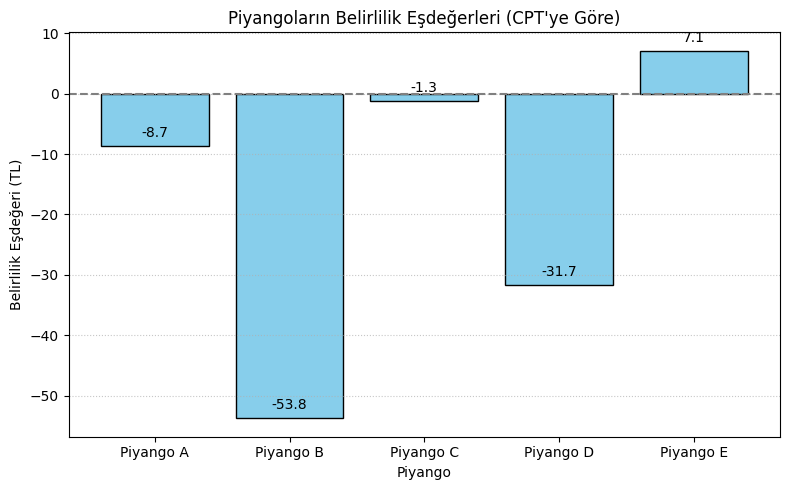

' En yüksek CE\'ye sahip olan piyango (en "tercih edilebilir") en yüksek çubuğa sahip olur. '

In [12]:
# KOD 3:
"""İstersen bu fonksiyonu birden fazla piyango için çağırabiliriz veya görselleştirme de ekleyebilirim. Sonraki adımda ne yapalım?

Şunu dedin:
birden fazla piyango için çağırabiliriz veya görselleştirme de ekleyelim

Harika! Aşağıda iki şeyi birleştiriyoruz:

🎯 1. Birden Fazla Piyango için CPT Hesaplaması
📈 2. Görselleştirme (Belirlilik Eşdeğerlerini Gösteren Grafik)
📌 Güncellenmiş Python Kodu:

"""
import numpy as np
import matplotlib.pyplot as plt

# CPT parametreleri
alpha = 0.88
beta = 0.88
lambd = 2.25
gamma = 0.61
delta = 0.69

# Değer fonksiyonu
def value_function(x):
    return x**alpha if x >= 0 else -lambd * ((-x)**beta)

# Olasılık ağırlık fonksiyonu
def weight_positive(p):
    return (p**gamma) / ((p**gamma + (1 - p)**gamma)**(1/gamma))

def weight_negative(p):
    return (p**delta) / ((p**delta + (1 - p)**delta)**(1/delta))

# CPT hesaplama fonksiyonu
def compute_cpt(outcomes, probabilities):
    if len(outcomes) != len(probabilities):
        raise ValueError("Sonuç ve olasılık uzunlukları eşit olmalı.")

    gains = [(x, p) for x, p in zip(outcomes, probabilities) if x >= 0]
    losses = [(x, p) for x, p in zip(outcomes, probabilities) if x < 0]

    v_gain = sum(value_function(x) * weight_positive(p) for x, p in gains)
    v_loss = sum(value_function(x) * weight_negative(p) for x, p in losses)

    total_value = v_gain + v_loss

    if total_value >= 0:
        ce = total_value ** (1 / alpha)
    else:
        ce = -((abs(total_value) / lambd) ** (1 / beta))

    return total_value, ce

# 🎲 Örnek piyango listesi
lotteries = [
    {"name": "Piyango A", "outcomes": [100, -50], "probabilities": [0.4, 0.6]},
    {"name": "Piyango B", "outcomes": [200, -150], "probabilities": [0.3, 0.7]},
    {"name": "Piyango C", "outcomes": [50, -30], "probabilities": [0.6, 0.4]},
    {"name": "Piyango D", "outcomes": [300, -100], "probabilities": [0.2, 0.8]},
    {"name": "Piyango E", "outcomes": [80, -20], "probabilities": [0.5, 0.5]},
]

# 📊 Sonuçları hesapla
names = []
ces = []

for l in lotteries:
    cpt_val, ce = compute_cpt(l["outcomes"], l["probabilities"])
    print(f"{l['name']} → CPT: {cpt_val:.2f}, CE: {ce:.2f} TL")
    names.append(l["name"])
    ces.append(ce)

# 📈 Görselleştirme: Belirlilik Eşdeğerleri
plt.figure(figsize=(8, 5))
bars = plt.bar(names, ces, color='skyblue', edgecolor='black')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Piyangoların Belirlilik Eşdeğerleri (CPT'ye Göre)")
plt.ylabel("Belirlilik Eşdeğeri (TL)")
plt.xlabel("Piyango")
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Etiketleri ekleyelim
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()




""" En yüksek CE'ye sahip olan piyango (en "tercih edilebilir") en yüksek çubuğa sahip olur. """





Yukarıdaki kod hücresindeki kod, birden fazla piyango için Kumulatif Beklenti Teorisi (CPT) hesaplamalarını yapar ve sonuçları görselleştirir. İşte kodun adım adım açıklaması:
1. Kütüphanelerin İçe Aktarılması:

import numpy as np: NumPy kütüphanesi, numerik hesaplamalar için kullanılır (dizi işlemleri, matematiksel fonksiyonlar vb.).
import matplotlib.pyplot as plt: Matplotlib kütüphanesi, verileri görselleştirmek için kullanılır (grafikler, çizelgeler vb.).

2. CPT Parametrelerinin Tanımlanması:

alpha, beta, lambd, gamma, delta: CPT modelinin parametreleri olarak tanımlanır. Bunlar, bireylerin risk ve kazanç/kayıplara karşı tutumlarını temsil eder.

3. Fonksiyonların Tanımlanması:

value_function(x): Bir sonucun değerini hesaplar. Kazançlar için x**alpha, kayıplar için -lambd * ((-x)**beta) formülünü kullanır.
weight_positive(p) ve weight_negative(p): Olasılıkların ağırlıklarını hesaplar. CPT'de, olasılıklar doğrusal olarak değil, ağırlıklandırılmış olarak kullanılır.
compute_cpt(outcomes, probabilities): Bir piyango için CPT değerini ve Belirlilik Eşdeğerini (CE) hesaplar.

4. Piyango Verilerinin Tanımlanması:

lotteries: Birden fazla piyango için verileri içeren bir liste. Her piyango, bir ad, sonuçlar ve olasılıklardan oluşur.

5. CPT Hesaplamaları ve Sonuçların Yazdırılması:

Bir döngü kullanarak, her piyango için compute_cpt fonksiyonu çağrılır ve CPT değeri ile CE (kesinlik eşdeğeri) hesaplanır.
Sonuçlar, piyango adı ile birlikte yazdırılır.

6. Görselleştirme:

Matplotlib kullanılarak, piyangoların Belirlilik Eşdeğerlerini gösteren bir bar grafiği oluşturulur.
Grafik, piyango adlarını x ekseninde, CE değerlerini y ekseninde gösterir.
Grafik başlığı, eksen etiketleri ve ızgara çizgileri eklenir.
Her çubuğun üzerine CE değeri yazdırılır.

Özetle:

Bu kod, birden fazla piyango için CPT hesaplamalarını yapar ve sonuçları görselleştirerek, farklı piyangoların bireyler tarafından nasıl algılandığını anlamamıza yardımcı olur. En yüksek CE'ye sahip piyango, bireyler tarafından en çok tercih edilen piyangodur.

**kesinlik eşdeğerini nasıl hesaplıyor**

Kod, kesinlik eşdeğerini (CE) hesaplamak için aşağıdaki adımları izler:

Toplam CPT Değerinin Hesaplanması:

compute_cpt fonksiyonu içinde, önce kazançlar ve kayıplar için ayrı ayrı değerler hesaplanır.
Bu değerler, ilgili olasılık ağırlıklarıyla çarpılır ve toplanarak toplam CPT değeri elde edilir.
CE'nin Hesaplanması:

Toplam CPT değeri pozitifse, CE değeri şu formülle hesaplanır:

    ce = total_value ** (1 / alpha)

Toplam CPT değeri negatifse, CE değeri şu formülle hesaplanır:

    ce = -((abs(total_value) / lambd) ** (1 / beta))


Burada alpha, beta ve lambd, CPT modelinin parametreleridir.

Özetle:

CE, bireyin bir piyangoya katılmak yerine, kesin olarak alacağı tutarı temsil eder. Yani, birey piyangoya katılarak elde edeceği beklenen değere eşit bir kesin tutarı tercih eder.

Örnek:

Diyelim ki bir piyangonun CPT değeri 10 ve alpha değeri 0.88 olsun. Bu durumda CE değeri şu şekilde hesaplanır:

    CE = 10 ** (1 / 0.88) ≈ 12.84

Yani, birey bu piyangoya katılmak yerine, kesin olarak 12.84 TL almayı tercih eder.

**PT yerine CPT kullanmanın mantığı nedir**

Beklenti Teorisi (PT) yerine Kumulatif Beklenti Teorisi'nin (CPT) kullanılmasının temel mantığı, CPT'nin insanların karar verme davranışlarını daha gerçekçi bir şekilde modellemesidir.

PT, insanların olasılıkları doğrusal olarak değerlendirdiğini varsayar, ancak gerçekte insanlar küçük olasılıkları abartma ve büyük olasılıkları küçümseme eğilimindedir. CPT, bu davranışı olasılık ağırlıklandırma fonksiyonları ile hesaba katarak daha doğru tahminler yapar.

İşte PT yerine CPT kullanmanın bazı avantajları:

Olasılık Ağırlıklandırması: CPT, insanların olasılıkları nasıl algıladığını daha iyi yansıtan olasılık ağırlıklandırma fonksiyonları kullanır. Bu, küçük olasılıkların abartılması ve büyük olasılıkların küçümsenmesi gibi gerçek hayatta gözlemlenen davranışları yakalar.

Kayıp İğrençliği: CPT, insanların kayıplara karşı kazançlardan daha duyarlı olduğunu hesaba katan "kayıp iğrençliği" kavramını içerir. Bu, insanların riskten kaçınma davranışlarını daha iyi açıklar.

Stokastik Baskınlığın İhlal Edilmemesi: PT, stokastik baskınlığı ihlal edebilir, yani daha düşük bir beklenen değere sahip bir seçeneği tercih edebilir. CPT, bu sorunu çözerek daha tutarlı sonuçlar sağlar.

Genelleştirilebilirlik: CPT, PT'ye göre daha genel bir teoridir ve farklı karar verme durumlarına daha kolay uygulanabilir.

Özetle:

CPT, insanların karar verme davranışlarını daha gerçekçi bir şekilde modellediği için PT'ye göre daha tercih edilir bir teoridir. Olasılık ağırlıklandırması, kayıp iğrençliği ve stokastik baskınlığın ihlal edilmemesi gibi özellikleri, CPT'yi daha güçlü ve güvenilir bir karar verme modeli haline getirir.

**CPT kesinlik eşdeğerinin mucidi kimdir**

Kesinlik eşdeğeri (CE) kavramı, doğrudan CPT ile ortaya çıkan bir kavram değildir. Daha eski bir kavramdır ve farklı isimlerle farklı kişiler tarafından kullanılmıştır.

CPT ile ilişkilendirildiği şekliyle CE'nin mucidi olarak, CPT'nin mucitleri olan Daniel Kahneman ve Amos Tversky gösterilebilir. Ancak CE, onların keşfi değildir.

CE kavramının geçmişi daha eskilere dayanır. Örneğin, 18. yüzyılda Daniel Bernoulli, St. Petersburg paradoksunu çözmek için "beklenen fayda" kavramını kullanmış ve bu kavram, CE ile yakından ilişkilidir.

CPT ile birlikte CE, karar verme teorisi ve davranışsal ekonomide yaygın olarak kullanılan bir kavram haline gelmiştir. CE, bir piyangonun veya belirsiz bir sonucun, birey için kesin bir miktar paraya eşdeğer olduğunu ifade eder.

Özetle, CE kavramının doğrudan bir mucidi olmasa da, CPT ile ilişkilendirildiği şekliyle Kahneman ve Tversky'nin çalışmaları önemli bir rol oynamıştır. Ancak, CE kavramı daha eskilere dayanır ve farklı kişiler tarafından farklı isimlerle kullanılmıştır.

